In [2]:
from pathlib import Path
import pandas as pd

# folder with cleaned outputs
data_dir = Path(r"C:\Users\riddh\OneDrive\Desktop\capital_one_challenge\processed_data")

def load_clean(base_name):
    pqt = data_dir / f"{base_name}.parquet"
    csv = data_dir / f"{base_name}.csv"
    if pqt.exists():
        return pd.read_parquet(pqt)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"Missing both: {pqt} and {csv}")

# load all 3
buyers = load_clean("buyers_clean")
products = load_clean("products_clean")   # if you saved as products.csv, change to "products"
sales = load_clean("sales_clean")         # if you only have clean_sales.csv, use pd.read_csv(data_dir / "clean_sales.csv")

# quick check
print("buyers :", buyers.shape)
print("products:", products.shape)
print("sales  :", sales.shape)


buyers : (47500, 14)
products: (1037, 15)
sales  : (344314, 7)


In [7]:
import pandas as pd
from pathlib import Path

data_dir = Path("processed_data")

# 1) Load raw data
buyers = pd.read_csv(data_dir / "buyers_clean.csv")
sales = pd.read_csv(data_dir / "clean_sales.csv")
products = pd.read_csv(data_dir / "products_clean.csv")

# 2) FIX: INNER JOIN buyers → sales (remove orphans FIRST)
buyers = buyers[buyers["buyer_id"].isin(sales["buyer_id"])].copy()
print(f"buyers after INNER JOIN fix: {buyers.shape}")  # Should be (22568, 14)

# 3) Now do the main joins (no row loss)
sales_buyers_inner = sales.merge(buyers, on="buyer_id", how="inner")
print(f"sales_buyers_inner: {sales_buyers_inner.shape}")  # Should be (344314, 20) - NO LOSS

# 4) Add products
final_inner = sales_buyers_inner.merge(products, on="sku_id", how="inner")
print(f"final_inner: {final_inner.shape}")  # Should be (344314, 34)


buyers after INNER JOIN fix: (23784, 14)
sales_buyers_inner: (327633, 20)
final_inner: (327633, 34)


In [9]:
import pandas as pd
from pathlib import Path

data_dir = Path("processed_data")
buyers = pd.read_csv(data_dir / "buyers_clean.csv")
sales = pd.read_csv(data_dir / "clean_sales.csv")

print("=== DIAGNOSIS ===")
print(f"Buyers rows: {buyers.shape[0]:,}")
print(f"Buyers unique IDs: {buyers['buyer_id'].nunique():,}")
print(f"Sales rows: {sales.shape[0]:,}")
print(f"Sales unique IDs: {sales['buyer_id'].nunique():,}")
print(f"Sales null buyer_ids: {sales['buyer_id'].isna().sum():,}")

# Check the overlap
buyers_ids = set(buyers['buyer_id'].dropna())
sales_ids = set(sales['buyer_id'].dropna())

print(f"\nBuyers with sales: {len(buyers_ids & sales_ids):,}")
print(f"Missing in buyers: {len(sales_ids - buyers_ids):,}")
print(f"In buyers but not sales: {len(buyers_ids - sales_ids):,}")

# Check data types
print(f"\nBuyer ID type: {buyers['buyer_id'].dtype}")
print(f"Sales ID type: {sales['buyer_id'].dtype}")


=== DIAGNOSIS ===
Buyers rows: 23,784
Buyers unique IDs: 23,784
Sales rows: 344,314
Sales unique IDs: 25,000
Sales null buyer_ids: 0

Buyers with sales: 23,784
Missing in buyers: 1,216
In buyers but not sales: 0

Buyer ID type: object
Sales ID type: object


In [10]:
# Join clean SALES + BUYERS + PRODUCTS

from pathlib import Path
import pandas as pd

data_dir = Path(r"C:\Users\riddh\OneDrive\Desktop\capital_one_challenge\processed_data")

def load_clean(base):
    pqt = data_dir / f"{base}.parquet"
    csv = data_dir / f"{base}.csv"
    if pqt.exists():
        return pd.read_parquet(pqt)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"Missing {base}.parquet/.csv")

# 1) Load clean datasets
buyers = load_clean("buyers_clean")
sales = load_clean("sales_clean")
products = load_clean("products_clean")

# 2) Normalize keys
buyers["buyer_id"] = buyers["buyer_id"].astype("string").str.strip()
sales["buyer_id"] = sales["buyer_id"].astype("string").str.strip()

sales["sku_id"] = sales["sku_id"].astype("string").str.strip().str.upper()
products["sku_id"] = products["sku_id"].astype("string").str.strip().str.upper()

# 3) INNER JOIN (only fully matched records)
sales_buyers = sales.merge(buyers, on="buyer_id", how="inner", suffixes=("", "_buyer"))
final_inner = sales_buyers.merge(products, on="sku_id", how="inner", suffixes=("", "_product"))

print("buyers      :", buyers.shape)
print("sales       :", sales.shape)
print("products    :", products.shape)
print("sales_buyers:", sales_buyers.shape)
print("final_inner :", final_inner.shape)

# Optional: save final joined dataset
final_inner.to_csv(data_dir / "final_joined_inner.csv", index=False)
final_inner.to_parquet(data_dir / "final_joined_inner.parquet", index=False)


buyers      : (23784, 14)
sales       : (344314, 7)
products    : (1037, 15)
sales_buyers: (327633, 20)
final_inner : (327633, 34)


In [12]:
import pandas as pd

df = final_inner.copy()

# Ensure datetime
df["order_datetime"] = pd.to_datetime(df["order_datetime"], errors="coerce")
df = df[df["order_datetime"].notna()].copy()

# Fallback timezone if missing
df["timezone"] = df["timezone"].fillna("America/Chicago")

# Convert customer-local -> company timezone (America/Chicago)
def to_company_tz(row):
    try:
        ts_local = row["order_datetime"].tz_localize(
            row["timezone"], ambiguous="NaT", nonexistent="NaT"
        )
        return ts_local.tz_convert("America/Chicago")
    except Exception:
        return pd.NaT

df["order_dt_company"] = df.apply(to_company_tz, axis=1)
df = df[df["order_dt_company"].notna()].copy()

# Hourly order volume
hourly = (
    df.groupby(df["order_dt_company"].dt.hour)
      .size()
      .reindex(range(24), fill_value=0)
      .rename("order_count")
      .reset_index()
      .rename(columns={"order_dt_company": "hour"})
)
hourly["pct"] = hourly["order_count"] / hourly["order_count"].sum() * 100

print(hourly)

# Quick staffing stats
overnight_hours = [0, 1, 2, 3, 4, 5]
overnight_pct = hourly[hourly["hour"].isin(overnight_hours)]["pct"].sum()
print(f"\nOvernight share (00:00-05:59): {overnight_pct:.2f}%")


    hour  order_count       pct
0      0         7532  2.298928
1      1         5010  1.529159
2      2         6357  1.940293
3      3         3709  1.132066
4      4         4729  1.443392
5      5         6328  1.931441
6      6         9000  2.746993
7      7        11796  3.600392
8      8        13908  4.245020
9      9        15281  4.664089
10    10        16351  4.990675
11    11        17194  5.247977
12    12        17265  5.269648
13    13        18139  5.536411
14    14        19295  5.889247
15    15        19981  6.098629
16    16        21050  6.424911
17    17        20832  6.358373
18    18        20574  6.279626
19    19        18844  5.751592
20    20        17126  5.227222
21    21        14262  4.353068
22    22        11570  3.531412
23    23        11498  3.509436

Overnight share (00:00-05:59): 10.28%


In [17]:
"""
QUESTION 2: Average Profit per Order by Quarter for Each Customer Segment
"""

import pandas as pd
import numpy as np

# Your final_inner dataset
final = final_inner.copy()

# Ensure datetime
final['order_datetime'] = pd.to_datetime(final['order_datetime'], errors='coerce')

# Extract quarter
final['quarter'] = final['order_datetime'].dt.quarter
final['year'] = final['order_datetime'].dt.year
final['year_quarter'] = final['year'].astype(str) + '-Q' + final['quarter'].astype(str)

print("=" * 90)
print("Q2: AVERAGE PROFIT PER ORDER BY QUARTER & CUSTOMER SEGMENT")
print("=" * 90)

# STEP 1: Calculate Base Order Value
final['base_order_value'] = final['price'] * final['quantity']

# STEP 2: Identify and Calculate Discounts
# Referral Discount (10% off first order for referred customers)
final = final.sort_values(['buyer_id', 'order_datetime']).reset_index(drop=True)
final['order_number'] = final.groupby('buyer_id').cumcount() + 1
final['is_first_order'] = final['order_number'] == 1
final['is_referral_discount'] = (final['is_referred'].fillna(0) == 1) & (final['is_first_order'])
final['referral_discount_amount'] = final['is_referral_discount'] * (final['base_order_value'] * 0.10)

# Black Friday Discount (20% off day after Thanksgiving)
def is_black_friday(dt):
    if pd.isna(dt):
        return False
    year = dt.year
    november = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30')
    thursdays = november[november.dayofweek == 3]
    if len(thursdays) >= 4:
        thanksgiving = thursdays[3]
        black_friday = thanksgiving + pd.Timedelta(days=1)
        return dt.date() == black_friday.date()
    return False

final['is_black_friday'] = final['order_datetime'].apply(is_black_friday)
final['black_friday_discount_amount'] = final['is_black_friday'] * (final['base_order_value'] * 0.20)

# Total discount (max of the two - don't stack)
final['total_discount'] = final[['referral_discount_amount', 'black_friday_discount_amount']].max(axis=1)

# STEP 3: Calculate Revenue
final['shipping_fee'] = 4.99
final['revenue'] = final['base_order_value'] - final['total_discount'] + final['shipping_fee']

# STEP 4: Calculate Cost and Profit
final['cost'] = final['base_order_value'] * (1 - final['margin'].fillna(0))
final['profit'] = final['revenue'] - final['cost'] - final['shipping_fee']

# STEP 5: Aggregate by Quarter & Customer Segment
result = (
    final.groupby(['year_quarter', 'customer_segment'])
    .agg({
        'profit': ['mean', 'sum', 'count'],
        'revenue': 'sum',
    })
    .round(2)
)

result.columns = ['avg_profit_per_order', 'total_profit', 'order_count', 'total_revenue']
result = result.reset_index()

print("\nAverage Profit per Order by Quarter & Segment:")
print(result.to_string(index=False))

# PIVOT for visualization
pivot = result.pivot(
    index='year_quarter',
    columns='customer_segment',
    values='avg_profit_per_order'
).round(2)

print("\n" + "=" * 90)
print("PIVOT: Average Profit per Order by Quarter")
print("=" * 90)
print(pivot)

# Summary by segment
print("\n" + "=" * 90)
print("SUMMARY: By Customer Segment (All Quarters)")
print("=" * 90)

segment_summary = final.groupby('customer_segment').agg({
    'profit': ['mean', 'count', 'sum'],
}).round(2)

segment_summary.columns = ['avg_profit_per_order', 'order_count', 'total_profit']
print(segment_summary)

# Key insights
print("\n" + "=" * 90)
print("KEY METRICS")
print("=" * 90)
print(f"Referral discounts impact: ${final['referral_discount_amount'].sum():,.2f}")
print(f"Black Friday discounts impact: ${final['black_friday_discount_amount'].sum():,.2f}")
print(f"Total orders analyzed: {len(final):,}")
print(f"Average profit per order: ${final['profit'].mean():.2f}")


Q2: AVERAGE PROFIT PER ORDER BY QUARTER & CUSTOMER SEGMENT

Average Profit per Order by Quarter & Segment:
year_quarter customer_segment  avg_profit_per_order  total_profit  order_count  total_revenue
     2024-Q1   Bargain Hunter                 22.62     111940.14         4948      261408.55
     2024-Q1     Beauty Lover                 21.02     107190.49         5099      246159.39
     2024-Q1   Cozy Homemaker                 19.51       87942.3         4507      229278.91
     2024-Q1  Fashion Shopper                 15.64      90986.84         5816      288147.64
     2024-Q1     Fitness Buff                 18.37      80174.66         4364      216903.85
     2024-Q1   Home Organizer                 20.36      92555.92         4545       233562.2
     2024-Q1  Tech Enthusiast                 47.77     321269.76         6725      710302.04
     2024-Q1     Young Parent                 29.64     147457.82         4975      354763.19
     2024-Q2   Bargain Hunter                 1

In [21]:
"""
QUESTION 3: Total Revenue Lost Due to Referral Program
Should we continue to offer discounts for referred customers?
"""

import pandas as pd
import numpy as np

# Use your joined dataset
final_q3 = final_inner.copy() if "final_inner" in globals() else final.copy()

print("=" * 90)
print("Q3: REVENUE LOST DUE TO REFERRAL PROGRAM")
print("=" * 90)

# -----------------------------------------------------------------------------
# 0) Prep + required columns
# -----------------------------------------------------------------------------
req = ["order_id", "buyer_id", "order_datetime", "is_referred", "customer_segment"]
missing = [c for c in req if c not in final_q3.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

final_q3["order_datetime"] = pd.to_datetime(final_q3["order_datetime"], errors="coerce")
final_q3["is_referred"] = pd.to_numeric(final_q3["is_referred"], errors="coerce").fillna(0).astype(int)
final_q3 = final_q3.dropna(subset=["order_id", "buyer_id", "order_datetime"]).copy()

# If referral discount already exists, use it.
# Otherwise compute from doc assumption: referred customers get 10% off first order.
if "referral_discount_amount" not in final_q3.columns:
    # Need price and quantity to compute discount amount
    if not all(c in final_q3.columns for c in ["price", "quantity"]):
        raise ValueError("Need either referral_discount_amount OR (price, quantity) columns.")
    final_q3["price"] = pd.to_numeric(final_q3["price"], errors="coerce")
    final_q3["quantity"] = pd.to_numeric(final_q3["quantity"], errors="coerce")
    final_q3["line_base_revenue"] = final_q3["price"] * final_q3["quantity"]

    first_order_dt = final_q3.groupby("buyer_id")["order_datetime"].min().rename("first_order_dt")
    final_q3 = final_q3.merge(first_order_dt, on="buyer_id", how="left")
    final_q3["is_first_order"] = final_q3["order_datetime"].eq(final_q3["first_order_dt"])

    final_q3["line_referral_discount"] = np.where(
        final_q3["is_referred"].eq(1) & final_q3["is_first_order"],
        final_q3["line_base_revenue"] * 0.10,
        0.0
    )
else:
    final_q3["line_referral_discount"] = pd.to_numeric(final_q3["referral_discount_amount"], errors="coerce").fillna(0)

# Revenue/profit fields
# Prefer existing revenue/profit if present; else compute basic from price/qty/margin.
if "revenue" in final_q3.columns:
    final_q3["line_revenue"] = pd.to_numeric(final_q3["revenue"], errors="coerce").fillna(0)
else:
    if not all(c in final_q3.columns for c in ["price", "quantity"]):
        raise ValueError("Need revenue column OR (price, quantity) columns.")
    final_q3["line_revenue"] = pd.to_numeric(final_q3["price"], errors="coerce").fillna(0) * \
                               pd.to_numeric(final_q3["quantity"], errors="coerce").fillna(0)

if "profit" in final_q3.columns:
    final_q3["line_profit"] = pd.to_numeric(final_q3["profit"], errors="coerce").fillna(0)
else:
    if "margin" not in final_q3.columns:
        raise ValueError("Need profit column OR margin column to compute profit.")
    final_q3["margin"] = pd.to_numeric(final_q3["margin"], errors="coerce").fillna(0)
    final_q3["line_profit"] = final_q3["line_revenue"] * final_q3["margin"]

# -----------------------------------------------------------------------------
# 1) Build ORDER-level table (critical fix)
# -----------------------------------------------------------------------------
orders = (
    final_q3.groupby(["order_id", "buyer_id"], as_index=False)
    .agg(
        order_dt=("order_datetime", "min"),
        customer_segment=("customer_segment", "first"),
        buyer_is_referred=("is_referred", "max"),
        order_revenue=("line_revenue", "sum"),
        order_profit=("line_profit", "sum"),
        referral_discount_amount=("line_referral_discount", "sum"),
    )
)

orders["is_referral_discount"] = orders["referral_discount_amount"] > 0

# -----------------------------------------------------------------------------
# PART 1: Direct Revenue Loss
# -----------------------------------------------------------------------------
print("\n[1] DIRECT REVENUE LOSS")
print("-" * 90)

total_referral_discount = orders["referral_discount_amount"].sum()
referral_orders = int(orders["is_referral_discount"].sum())
avg_discount = (total_referral_discount / referral_orders) if referral_orders else 0.0

print(f"Total referral discounts given: ${total_referral_discount:,.2f}")
print(f"Orders with referral discount: {referral_orders:,}")
print(f"Average discount per referred order: ${avg_discount:.2f}")

# -----------------------------------------------------------------------------
# PART 2: Referred vs Non-Referred (order-level + customer-level)
# -----------------------------------------------------------------------------
print("\n[2] REFERRAL PROGRAM IMPACT ANALYSIS")
print("-" * 90)

ref_orders = orders[orders["buyer_is_referred"] == 1].copy()
nonref_orders = orders[orders["buyer_is_referred"] == 0].copy()

def safe_div(a, b):
    return a / b if b else np.nan

ref_customers = ref_orders["buyer_id"].nunique()
nonref_customers = nonref_orders["buyer_id"].nunique()

comparison = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Orders",
        "Avg Orders per Customer",
        "Avg Profit per Order",
        "Total Profit",
        "Avg Revenue per Order",
        "Total Revenue"
    ],
    "Referred": [
        ref_customers,
        len(ref_orders),
        safe_div(len(ref_orders), ref_customers),
        ref_orders["order_profit"].mean(),
        ref_orders["order_profit"].sum(),
        ref_orders["order_revenue"].mean(),
        ref_orders["order_revenue"].sum()
    ],
    "Non-Referred": [
        nonref_customers,
        len(nonref_orders),
        safe_div(len(nonref_orders), nonref_customers),
        nonref_orders["order_profit"].mean(),
        nonref_orders["order_profit"].sum(),
        nonref_orders["order_revenue"].mean(),
        nonref_orders["order_revenue"].sum()
    ]
})
comparison["Difference (Referred - Non-Referred)"] = comparison["Referred"] - comparison["Non-Referred"]
print("\n" + comparison.to_string(index=False))

# -----------------------------------------------------------------------------
# PART 3: Lifetime / repeat analysis (customer-level fix)
# -----------------------------------------------------------------------------
print("\n[3] CUSTOMER LIFETIME VALUE")
print("-" * 90)

referred_ltv = (
    ref_orders.groupby("buyer_id", as_index=False)
    .agg(
        total_profit=("order_profit", "sum"),
        total_revenue=("order_revenue", "sum"),
        order_count=("order_id", "nunique")
    )
)
referred_ltv["has_repeat"] = referred_ltv["order_count"] > 1

repeat_cnt = int(referred_ltv["has_repeat"].sum())
single_cnt = int((~referred_ltv["has_repeat"]).sum())
repeat_pct = (repeat_cnt / len(referred_ltv) * 100) if len(referred_ltv) else 0
single_pct = (single_cnt / len(referred_ltv) * 100) if len(referred_ltv) else 0

print(f"Referred customers with repeat purchases: {repeat_cnt:,} ({repeat_pct:.1f}%)")
print(f"Referred customers with single purchase: {single_cnt:,} ({single_pct:.1f}%)")
print(f"\nRepeated customers avg lifetime profit: ${referred_ltv[referred_ltv['has_repeat']]['total_profit'].mean():.2f}")

single_avg = referred_ltv[~referred_ltv["has_repeat"]]["total_profit"].mean()
print(f"Single-purchase customers avg profit: ${single_avg:.2f}" if pd.notna(single_avg) else "Single-purchase customers avg profit: N/A")

# -----------------------------------------------------------------------------
# PART 4: Cost-benefit
# -----------------------------------------------------------------------------
print("\n[4] COST-BENEFIT ANALYSIS")
print("-" * 90)

actual_referred_profit = ref_orders["order_profit"].sum()  # already includes discounts
counterfactual_no_ref_discount = actual_referred_profit + total_referral_discount
lost_profit_due_to_discount = total_referral_discount

print(f"Discount cost (revenue lost): ${total_referral_discount:,.2f}")
print(f"Actual profit from referred customers: ${actual_referred_profit:,.2f}")
print(f"Estimated profit without referral discount: ${counterfactual_no_ref_discount:,.2f}")
print(f"Lost profit opportunity from discounts: ${lost_profit_due_to_discount:,.2f}")

# -----------------------------------------------------------------------------
# PART 5: Segment view
# -----------------------------------------------------------------------------
print("\n[5] REFERRAL PROGRAM VALUE BY SEGMENT")
print("-" * 90)

segment_analysis = (
    ref_orders.groupby("customer_segment", as_index=True)
    .agg(
        unique_customers=("buyer_id", "nunique"),
        avg_profit=("order_profit", "mean"),
        total_profit=("order_profit", "sum"),
        order_count=("order_id", "nunique"),
        discount_given=("referral_discount_amount", "sum")
    )
    .round(2)
)

segment_analysis["net_profit"] = segment_analysis["total_profit"]  # already net
segment_analysis["discount_efficiency"] = np.where(
    segment_analysis["discount_given"] > 0,
    (segment_analysis["total_profit"] / segment_analysis["discount_given"]).round(1),
    np.nan
)

print("\n" + segment_analysis.to_string())

# -----------------------------------------------------------------------------
# PART 6: Recommendation
# -----------------------------------------------------------------------------
print("\n[6] KEY FINDINGS & RECOMMENDATION")
print("=" * 90)

referral_order_pct = (referral_orders / len(orders) * 100) if len(orders) else 0
profit_diff = ref_orders["order_profit"].mean() - nonref_orders["order_profit"].mean()

higher_or_similar = "higher" if profit_diff > 0 else "similar/lower"

print(f"""
KEY FINDINGS:
1. Revenue Lost (Referral Discounts): ${total_referral_discount:,.2f}
   - Discounted orders: {referral_orders:,} ({referral_order_pct:.1f}% of all orders)
   - Avg discount per discounted order: ${avg_discount:.2f}

2. Profitability:
   - Avg profit/order (referred): ${ref_orders['order_profit'].mean():.2f}
   - Avg profit/order (non-referred): ${nonref_orders['order_profit'].mean():.2f}
   - Difference: ${profit_diff:.2f}

3. Referred repeat rate:
   - {repeat_pct:.1f}% among referred customers in this analysis set

4. Counterfactual:
   - Estimated referred profit without discount: ${counterfactual_no_ref_discount:,.2f}
   - Profit opportunity lost to discounts: ${lost_profit_due_to_discount:,.2f}
""")

if profit_diff >= 0:
    print(f"""RECOMMENDATION:
✓ CONTINUE referral program, with monitoring.
Rationale: referred customers show {higher_or_similar} profit/order; discount cost is measurable and manageable.
Action: keep program, track quarterly discount efficiency by segment, and tune discount rate if needed.
""")
else:
    print(f"""RECOMMENDATION:
✗ REWORK referral program.
Rationale: referred customers show {higher_or_similar} profit/order after discount impact.
Action: reduce discount %, tighten eligibility, and A/B test revised terms.
""")

print("=" * 90)


Q3: REVENUE LOST DUE TO REFERRAL PROGRAM

[1] DIRECT REVENUE LOSS
------------------------------------------------------------------------------------------
Total referral discounts given: $25,781.77
Orders with referral discount: 3,563
Average discount per referred order: $7.24

[2] REFERRAL PROGRAM IMPACT ANALYSIS
------------------------------------------------------------------------------------------

                 Metric     Referred  Non-Referred  Difference (Referred - Non-Referred)
        Total Customers 3.563000e+03  2.022100e+04                         -1.665800e+04
           Total Orders 3.472800e+04  1.954490e+05                         -1.607210e+05
Avg Orders per Customer 9.746843e+00  9.665645e+00                          8.119792e-02
   Avg Profit per Order 4.046732e+01  3.802422e+01                          2.443094e+00
           Total Profit 1.405349e+06  7.431797e+06                         -6.026448e+06
  Avg Revenue per Order 9.334119e+01  8.672590e+01      

In [22]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

print("=" * 90)
print("Q4: BLACK FRIDAY IMPACT ON ANNUAL VOLUME/REVENUE BY CUSTOMER SEGMENT")
print("=" * 90)

df = final_inner.copy()

# -----------------------------
# Required cols
# -----------------------------
req = ["order_id", "order_datetime", "customer_segment", "price", "quantity"]
missing = [c for c in req if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Types
df["order_datetime"] = pd.to_datetime(df["order_datetime"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df = df.dropna(subset=["order_id", "order_datetime", "customer_segment", "price", "quantity"]).copy()

# Base revenue at line level
df["line_revenue_base"] = df["price"] * df["quantity"]

# -----------------------------
# Black Friday date = Friday after Thanksgiving
# -----------------------------
def black_friday(y: int) -> date:
    d = date(y, 11, 1)
    first_thu = d + timedelta(days=(3 - d.weekday()) % 7)  # Thu=3
    fourth_thu = first_thu + timedelta(weeks=3)
    return fourth_thu + timedelta(days=1)

df["order_date"] = df["order_datetime"].dt.date
years = sorted(df["order_datetime"].dt.year.dropna().unique())
bf_map = {int(y): black_friday(int(y)) for y in years}
df["is_black_friday"] = df["order_datetime"].dt.year.map(bf_map).eq(df["order_date"])

# Doc rule: BF 20% reduction NOT reflected in price => apply discount
df["line_revenue_net"] = np.where(df["is_black_friday"], df["line_revenue_base"] * 0.80, df["line_revenue_base"])

# -----------------------------
# Order-level aggregation
# -----------------------------
orders = (
    df.groupby(["order_id", "customer_segment"], as_index=False)
      .agg(
          order_dt=("order_datetime", "min"),
          is_black_friday=("is_black_friday", "max"),
          order_revenue_base=("line_revenue_base", "sum"),
          order_revenue_net=("line_revenue_net", "sum")
      )
)
orders["year"] = orders["order_dt"].dt.year.astype(int)

# Annual totals by segment
annual_seg = (
    orders.groupby(["year", "customer_segment"], as_index=False)
          .agg(
              annual_orders=("order_id", "nunique"),
              annual_revenue_net=("order_revenue_net", "sum")
          )
)

# BF day totals by segment
bf_seg = (
    orders[orders["is_black_friday"]]
    .groupby(["year", "customer_segment"], as_index=False)
    .agg(
        bf_orders=("order_id", "nunique"),
        bf_revenue_base=("order_revenue_base", "sum"),
        bf_revenue_net=("order_revenue_net", "sum")
    )
)

# Combine + impact metrics
impact = annual_seg.merge(bf_seg, on=["year", "customer_segment"], how="left")
for c in ["bf_orders", "bf_revenue_base", "bf_revenue_net"]:
    impact[c] = impact[c].fillna(0)

impact["bf_order_share_pct"] = np.where(
    impact["annual_orders"] > 0,
    impact["bf_orders"] / impact["annual_orders"] * 100,
    0
)

impact["bf_revenue_share_pct"] = np.where(
    impact["annual_revenue_net"] > 0,
    impact["bf_revenue_net"] / impact["annual_revenue_net"] * 100,
    0
)

# Revenue reduction from BF discount
impact["bf_discount_impact"] = impact["bf_revenue_base"] - impact["bf_revenue_net"]
impact["bf_discount_impact_pct_of_annual"] = np.where(
    impact["annual_revenue_net"] > 0,
    impact["bf_discount_impact"] / impact["annual_revenue_net"] * 100,
    0
)

impact = impact.sort_values(["year", "customer_segment"]).round(2)

print("\nImpact table:")
print(impact.to_string(index=False))

# Optional condensed view
summary = (
    impact.groupby("customer_segment", as_index=False)
          .agg(
              avg_bf_order_share_pct=("bf_order_share_pct", "mean"),
              avg_bf_revenue_share_pct=("bf_revenue_share_pct", "mean"),
              total_bf_discount_impact=("bf_discount_impact", "sum")
          )
          .sort_values("avg_bf_revenue_share_pct", ascending=False)
          .round(2)
)

print("\nSegment summary (across years):")
print(summary.to_string(index=False))


Q4: BLACK FRIDAY IMPACT ON ANNUAL VOLUME/REVENUE BY CUSTOMER SEGMENT

Impact table:
 year customer_segment  annual_orders  annual_revenue_net  bf_orders  bf_revenue_base  bf_revenue_net  bf_order_share_pct  bf_revenue_share_pct  bf_discount_impact  bf_discount_impact_pct_of_annual
 2024   Bargain Hunter          14612           910291.66        157         12263.56         9810.85                1.07                  1.08             2452.71                              0.27
 2024     Beauty Lover          14338           912589.06        167         14318.46        11454.77                1.16                  1.26             2863.69                              0.31
 2024   Cozy Homemaker          14452          1147205.51        173         12056.64         9645.31                1.20                  0.84             2411.33                              0.21
 2024  Fashion Shopper          14444          1043800.29        163         18914.16        15135.33                1.13   

In [25]:
"""
QUESTION 5: Where is our best customer base?
What KPIs should we track to acquire more customers?
"""

import pandas as pd
import matplotlib.pyplot as plt

final_q5 = final.copy()

print("=" * 90)
print("Q5: BEST CUSTOMER BASE & ACQUISITION KPIS")
print("=" * 90)

# ============================================================================
# PART 1: Identify Best Customer Segments
# ============================================================================

print("\n[1] SEGMENT PROFITABILITY ANALYSIS")
print("-" * 90)

segment_analysis = final_q5.groupby('customer_segment').agg({
    'buyer_id': 'nunique',
    'order_id': 'count',
    'profit': ['mean', 'sum'],
    'revenue': 'sum',
    'quantity': 'sum'
}).round(2)

segment_analysis.columns = ['unique_customers', 'total_orders', 'avg_profit_per_order', 
                             'total_profit', 'total_revenue', 'total_quantity']

segment_analysis['orders_per_customer'] = (
    segment_analysis['total_orders'] / segment_analysis['unique_customers']
).round(2)

segment_analysis['profit_per_customer'] = (
    segment_analysis['total_profit'] / segment_analysis['unique_customers']
).round(2)

segment_analysis = segment_analysis.sort_values('total_profit', ascending=False)

print("\nSegment Performance:")
print(segment_analysis.to_string())

# Identify best segment
best_segment = segment_analysis.index[0]
best_profit = segment_analysis.iloc[0]['avg_profit_per_order']

print(f"\n>>> BEST SEGMENT: {best_segment}")
print(f"    Avg profit per order: ${best_profit:.2f}")
print(f"    Total customers: {int(segment_analysis.iloc[0]['unique_customers']):,}")

# ============================================================================
# PART 2: Geographic Analysis
# ============================================================================

print("\n[2] GEOGRAPHIC ANALYSIS")
print("-" * 90)

geo_analysis = final_q5.groupby('state').agg({
    'buyer_id': 'nunique',
    'order_id': 'count',
    'profit': ['mean', 'sum'],
    'revenue': 'sum'
}).round(2)

geo_analysis.columns = ['unique_customers', 'total_orders', 'avg_profit_per_order', 
                         'total_profit', 'total_revenue']

geo_analysis['market_share'] = (
    geo_analysis['unique_customers'] / geo_analysis['unique_customers'].sum() * 100
).round(1)

geo_analysis = geo_analysis.sort_values('total_profit', ascending=False)

print("\nTop 10 States by Profit:")
print(geo_analysis.head(10).to_string())

best_state = geo_analysis.index[0]
print(f"\n>>> BEST GEOGRAPHIC MARKET: {best_state}")
print(f"    Customers: {int(geo_analysis.iloc[0]['unique_customers']):,}")
print(f"    Market share: {geo_analysis.iloc[0]['market_share']:.1f}%")

# ============================================================================
# PART 3: Customer Segment + Geography Cross-tabulation
# ============================================================================

print("\n[3] BEST CUSTOMER SEGMENT x GEOGRAPHY")
print("-" * 90)

# Combine best segment with geography
best_combo = final_q5[final_q5['customer_segment'] == best_segment].groupby('state').agg({
    'buyer_id': 'nunique',
    'profit': ['mean', 'sum']
}).round(2)

best_combo.columns = ['customers', 'avg_profit', 'total_profit']
best_combo = best_combo.sort_values('total_profit', ascending=False)

print(f"\n{best_segment} customers by state:")
print(best_combo.head(10).to_string())

best_state_segment = best_combo.index[0]
print(f"\n>>> HIGHEST OPPORTUNITY: {best_segment} in {best_state_segment}")

# ============================================================================
# PART 4: Repeat Purchase Rate & Loyalty
# ============================================================================

print("\n[4] CUSTOMER LOYALTY ANALYSIS")
print("-" * 90)

final_q5_sorted = final_q5.sort_values(['buyer_id', 'order_datetime']).reset_index(drop=True)
final_q5_sorted['order_number'] = final_q5_sorted.groupby('buyer_id').cumcount() + 1

loyalty = final_q5_sorted.groupby('customer_segment').agg({
    'buyer_id': 'nunique',
    'order_number': 'max'  # max order number = total orders
}).reset_index()

loyalty.columns = ['customer_segment', 'total_customers', 'avg_orders_per_customer']

# Calculate repeat rate
first_time = (final_q5_sorted['order_number'] == 1).sum()
repeat = (final_q5_sorted['order_number'] > 1).sum()

loyalty_by_segment = final_q5_sorted.groupby('customer_segment')['order_number'].agg(
    lambda x: (x > 1).sum() / len(x) * 100
).round(1)

print(f"\nRepeat Purchase Rate by Segment:")
for seg in loyalty_by_segment.index:
    print(f"  {seg}: {loyalty_by_segment[seg]:.1f}%")

best_loyalty = loyalty_by_segment.idxmax()
print(f"\n>>> BEST LOYALTY: {best_loyalty} ({loyalty_by_segment[best_loyalty]:.1f}% repeat rate)")

# ============================================================================
# PART 5: Growth Potential
# ============================================================================

print("\n[5] GROWTH POTENTIAL ANALYSIS")
print("-" * 90)

# Analyze by quarter to see trends
final_q5['quarter'] = pd.to_datetime(final_q5['order_datetime']).dt.quarter
final_q5['year'] = pd.to_datetime(final_q5['order_datetime']).dt.year
final_q5['year_quarter'] = final_q5['year'].astype(str) + '-Q' + final_q5['quarter'].astype(str)

growth = final_q5.groupby(['year_quarter', 'customer_segment'])['buyer_id'].nunique().reset_index()
growth.columns = ['year_quarter', 'customer_segment', 'new_customers']

growth_pivot = growth.pivot(index='year_quarter', columns='customer_segment', values='new_customers')

print("\nCustomer Acquisition by Quarter:")
print(growth_pivot.to_string())

# Calculate growth rate
for seg in best_segment:
    if seg in growth_pivot.columns:
        first_q = growth_pivot[seg].iloc[0]
        last_q = growth_pivot[seg].iloc[-1]
        growth_rate = ((last_q - first_q) / first_q * 100) if first_q > 0 else 0
        print(f"\n{seg} growth rate: {growth_rate:.1f}%")

# ============================================================================
# PART 6: KPI Recommendations
# ============================================================================

print("\n[6] RECOMMENDED KPIs TO TRACK")
print("=" * 90)

kpis = """
KEY PERFORMANCE INDICATORS (KPIs) FOR ACQUISITION:

1. CUSTOMER ACQUISITION METRICS:
   - Customer Acquisition Cost (CAC) by segment
   - New customers acquired by quarter/month
   - Acquisition channel effectiveness (if tracked)
   - Cost per acquisition by geography

2. RETENTION METRICS:
   - Repeat purchase rate by segment
   - Customer lifetime value (LTV) by segment
   - Churn rate by customer segment
   - Time between orders (purchase frequency)

3. SEGMENT-SPECIFIC METRICS:
   - Average profit per customer by segment
   - Orders per customer by geography
   - Product category preferences by segment
   - Seasonal trends by segment

4. GEOGRAPHIC METRICS:
   - Market penetration rate by state
   - Customer density (customers per capita)
   - Geographic expansion opportunities
   - Regional growth trends

5. REFERRAL PROGRAM METRICS:
   - Referred customer acquisition cost
   - Referred vs non-referred LTV comparison
   - Referral conversion rate
   - Cost per referred acquisition

6. REVENUE METRICS:
   - Average order value by segment
   - Profit margin by segment
   - Revenue per customer
   - AOV trend over time
"""

print(kpis)

# ============================================================================
# PART 7: ACTION PLAN
# ============================================================================

print("\n[7] RECOMMENDED ACTION PLAN")
print("=" * 90)

action_plan = f"""
IMMEDIATE ACTIONS:

1. Focus Acquisition on {best_segment}:
   - This segment has the highest profit potential (${best_profit:.2f}/order)
   - Currently {int(segment_analysis.loc[best_segment, 'unique_customers']):,} customers
   - Target: Increase by 20% in next quarter

2. Geographic Priority: {best_state_segment}:
   - {best_segment} segment performs best in {best_state_segment}
   - Concentrate marketing spend in this region
   - Look for similar markets for expansion

3. Improve Loyalty in {best_loyalty}:
   - {best_loyalty} has highest repeat rate ({loyalty_by_segment[best_loyalty]:.1f}%)
   - Invest in retention programs for this segment
   - Create segment-specific offerings

4. Track These Monthly:
   - New customers acquired by segment
   - Repeat purchase rate trends
   - LTV vs CAC by channel
   - Regional market share

5. Next Quarter Goals:
   - Increase {best_segment} customers by 20%
   - Improve repeat purchase rate by 5%
   - Reduce CAC by 10% through optimization
"""

print(action_plan)

print("=" * 90)


Q5: BEST CUSTOMER BASE & ACQUISITION KPIS

[1] SEGMENT PROFITABILITY ANALYSIS
------------------------------------------------------------------------------------------

Segment Performance:
                  unique_customers  total_orders  avg_profit_per_order  total_profit  total_revenue  total_quantity  orders_per_customer  profit_per_customer
customer_segment                                                                                                                                             
Tech Enthusiast               3013         53697                  54.1    2904834.47     6655559.92         63401.0                17.82                964.1
Young Parent                  2899         39678                 23.29     924294.85     2463314.09         59411.0                13.69               318.83
Home Organizer                3014         36330                 25.12     912742.93     2113622.57         46054.0                12.05               302.83
Cozy Homemaker     

In [ ]:
# Q5 (Alternative): Plotly US choropleth for customer value by state

import plotly.express as px
import pandas as pd
import numpy as np

# If not already available from prior cells:
# q5 = order_level.copy()

state_value = (
    order_level.groupby("state", as_index=False)
    .agg(
        total_profit=("order_profit", "sum"),
        unique_customers=("buyer_id", "nunique"),
        total_orders=("order_id", "nunique")
    )
)

state_value["profit_per_customer"] = state_value["total_profit"] / state_value["unique_customers"]
state_value["profit_per_order"] = state_value["total_profit"] / state_value["total_orders"]

# keep valid 2-letter US state codes
state_value["state"] = state_value["state"].astype(str).str.strip().str.upper()
state_value = state_value[state_value["state"].str.fullmatch(r"[A-Z]{2}", na=False)].copy()

fig = px.choropleth(
    state_value,
    locations="state",
    locationmode="USA-states",
    color="profit_per_customer",
    scope="usa",
    color_continuous_scale="YlGnBu",
    hover_data={
        "state": True,
        "profit_per_customer": ":.2f",
        "profit_per_order": ":.2f",
        "total_profit": ":.2f",
        "unique_customers": True,
        "total_orders": True
    },
    title="Q5: Geographic Customer Value (Profit per Customer) by State"
)

fig.update_layout(
    title_x=0.5,
    margin=dict(l=20, r=20, t=60, b=20),
    coloraxis_colorbar=dict(title="Profit / Customer")
)

fig.show()


final_inner: (327633, 34)


In [27]:
# CELL B: Assumption-compliant derived fields for Q1-Q5
from datetime import date, timedelta

# Source data
base = final_inner.copy()

# Required columns check
req = ["order_id", "buyer_id", "order_datetime", "price", "quantity", "margin", "is_referred", "customer_segment", "state", "region"]
missing = [c for c in req if c not in base.columns]
if missing:
    raise ValueError(f"Missing required columns in final_inner: {missing}")

# Type cleanup
base["order_datetime"] = pd.to_datetime(base["order_datetime"], errors="coerce")
base["price"] = pd.to_numeric(base["price"], errors="coerce")
base["quantity"] = pd.to_numeric(base["quantity"], errors="coerce")
base["margin"] = pd.to_numeric(base["margin"], errors="coerce")
base["is_referred"] = pd.to_numeric(base["is_referred"], errors="coerce").fillna(0).astype(int)

base = base.dropna(subset=["order_datetime", "price", "quantity", "margin"]).copy()

# --- Assumption: customer timestamps are customer-local; company is Missouri (America/Chicago)
base["timezone"] = base.get("timezone", pd.Series(index=base.index, dtype='object')).fillna("America/Chicago")

def to_company_tz(row):
    try:
        ts_local = row["order_datetime"].tz_localize(row["timezone"], ambiguous="NaT", nonexistent="NaT")
        return ts_local.tz_convert("America/Chicago")
    except Exception:
        return pd.NaT

base["order_dt_company"] = base.apply(to_company_tz, axis=1)
base = base[base["order_dt_company"].notna()].copy()

# Line-level base economics
base["line_base_revenue"] = base["price"] * base["quantity"]
base["line_cogs"] = base["line_base_revenue"] * (1 - base["margin"])

# Black Friday helper: Friday after Thanksgiving

def black_friday(y: int) -> date:
    d = date(y, 11, 1)
    first_thu = d + timedelta(days=(3 - d.weekday()) % 7)  # Thu=3
    fourth_thu = first_thu + timedelta(weeks=3)
    return fourth_thu + timedelta(days=1)

base["order_date_company"] = base["order_dt_company"].dt.date
years = sorted(base["order_dt_company"].dt.year.dropna().unique())
bf_map = {int(y): black_friday(int(y)) for y in years}
base["is_black_friday"] = base["order_dt_company"].dt.year.map(bf_map).eq(base["order_date_company"])

# First order for referral discount logic (10% off first order for referred customers)
first_order_dt = base.groupby("buyer_id")["order_dt_company"].min().rename("first_order_dt")
base = base.merge(first_order_dt, on="buyer_id", how="left")
base["is_first_order"] = base["order_dt_company"].eq(base["first_order_dt"])
base["ref_disc_rate"] = ((base["is_referred"].eq(1)) & (base["is_first_order"])).astype(float) * 0.10
base["bf_disc_rate"] = base["is_black_friday"].astype(float) * 0.20

# Apply both discounts multiplicatively
base["line_net_revenue"] = base["line_base_revenue"] * (1 - base["ref_disc_rate"]) * (1 - base["bf_disc_rate"])
base["line_referral_discount"] = base["line_base_revenue"] * base["ref_disc_rate"]
base["line_black_friday_discount"] = base["line_base_revenue"] * (1 - base["ref_disc_rate"]) * base["bf_disc_rate"]

# Aggregate to order-level
order_level = (
    base.groupby(["order_id", "buyer_id", "customer_segment", "state", "region"], as_index=False)
        .agg(
            order_datetime_company=("order_dt_company", "min"),
            is_referred=("is_referred", "max"),
            is_first_order=("is_first_order", "max"),
            is_black_friday=("is_black_friday", "max"),
            order_base_revenue=("line_base_revenue", "sum"),
            order_net_revenue_before_shipping=("line_net_revenue", "sum"),
            order_cogs=("line_cogs", "sum"),
            referral_discount_amount=("line_referral_discount", "sum"),
            black_friday_discount_amount=("line_black_friday_discount", "sum")
        )
)

# Shipping assumptions
order_level["customer_shipping_fee"] = np.select(
    [
        order_level["order_net_revenue_before_shipping"] < 50,
        (order_level["order_net_revenue_before_shipping"] >= 50) & (order_level["order_net_revenue_before_shipping"] < 100),
        order_level["order_net_revenue_before_shipping"] >= 100,
    ],
    [7.99, 4.99, 0.00],
    default=0.00,
)
order_level["company_shipping_cost"] = 4.99

# Final revenue/profit at order level (ignore taxes per prompt)
order_level["order_revenue"] = order_level["order_net_revenue_before_shipping"] + order_level["customer_shipping_fee"]
order_level["order_profit"] = order_level["order_revenue"] - order_level["order_cogs"] - order_level["company_shipping_cost"]

# Convenience fields used by charts
order_level["year"] = order_level["order_datetime_company"].dt.year
order_level["quarter"] = order_level["order_datetime_company"].dt.to_period("Q").astype(str)
order_level["hour_company"] = order_level["order_datetime_company"].dt.hour
order_level["is_referral_discount"] = order_level["referral_discount_amount"] > 0

print("order_level shape:", order_level.shape)
print("order date range (company time):", order_level["order_datetime_company"].min(), "to", order_level["order_datetime_company"].max())
print("referral discounts total:", round(order_level["referral_discount_amount"].sum(), 2))
print("black friday discounts total:", round(order_level["black_friday_discount_amount"].sum(), 2))



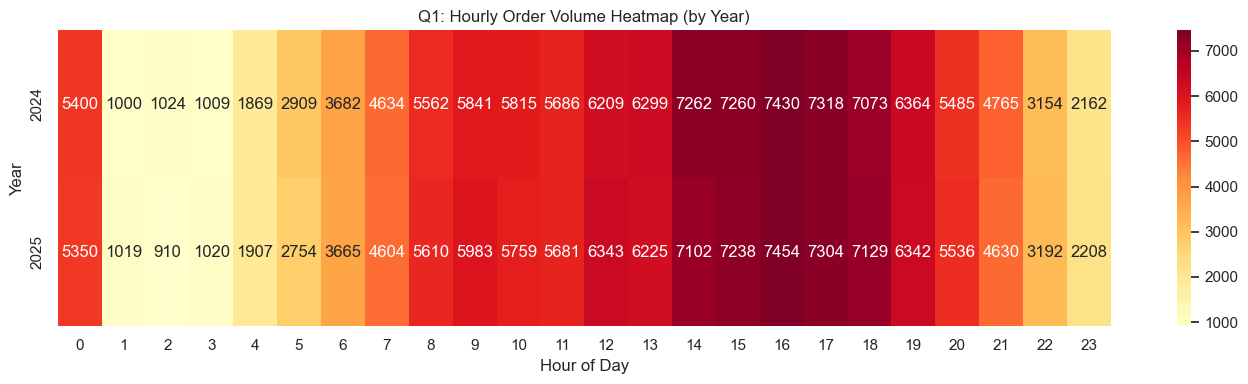

In [29]:
# Q1: Hourly order volume heatmap (company timezone)
q1 = order_level.copy()

hourly = q1.groupby(["year", "hour_company"]).size().reset_index(name="order_count")
heat = hourly.pivot(index="year", columns="hour_company", values="order_count").fillna(0)

plt.figure(figsize=(14, 4))
sns.heatmap(heat, cmap="YlOrRd", annot=True, fmt=".0f")
plt.title("Q1: Hourly Order Volume Heatmap (Company Time: America/Chicago)")
plt.xlabel("Hour of Day")
plt.ylabel("Year")
plt.tight_layout()
plt.show()



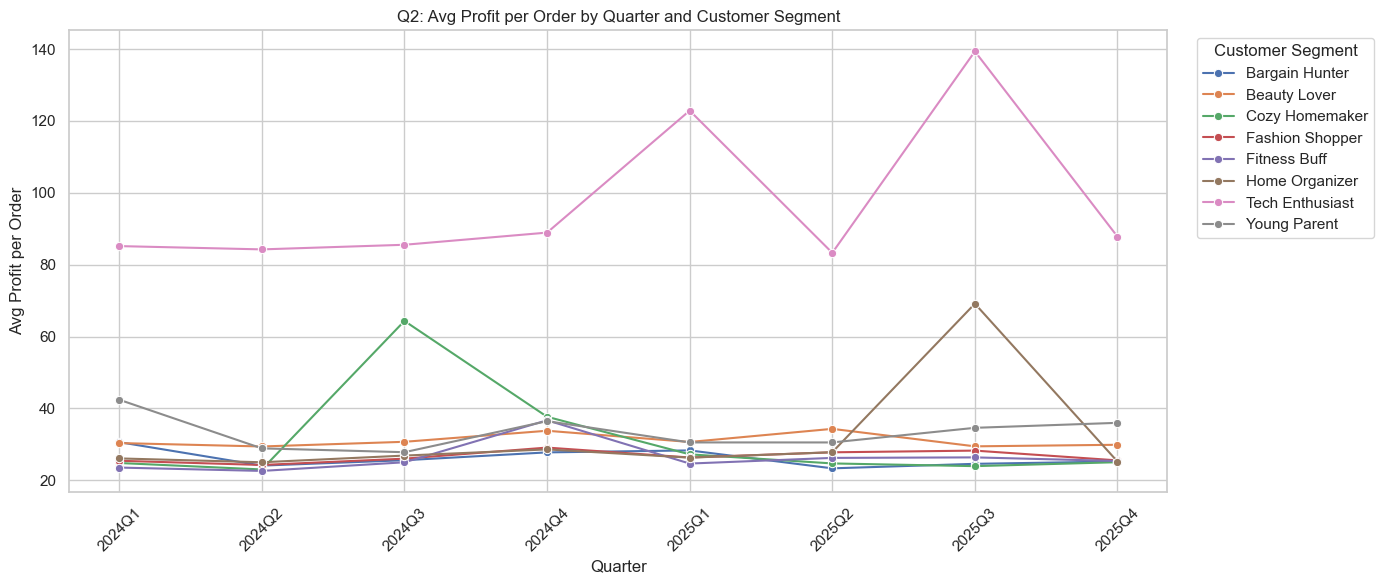

In [30]:
# Q2: Profit trend line chart (avg profit/order by quarter per segment)
q2_tbl = (
    order_level.groupby(["quarter", "customer_segment"], as_index=False)["order_profit"]
    .mean()
    .rename(columns={"order_profit": "avg_profit_per_order"})
    .sort_values(["quarter", "customer_segment"])
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=q2_tbl, x="quarter", y="avg_profit_per_order", hue="customer_segment", marker="o")
plt.title("Q2: Avg Profit per Order by Quarter and Customer Segment")
plt.xlabel("Quarter")
plt.ylabel("Avg Profit per Order")
plt.xticks(rotation=45)
plt.legend(title="Customer Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



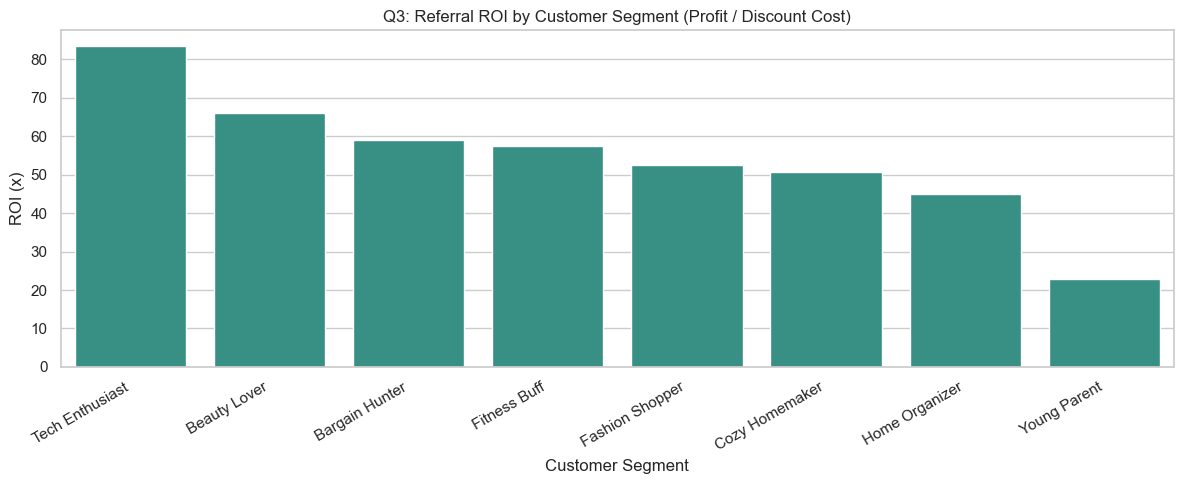

In [31]:
# Q3: Referral ROI comparison chart (by customer segment)
q3_ref = order_level[order_level["is_referred"].eq(1)].copy()

seg = (
    q3_ref.groupby("customer_segment", as_index=False)
    .agg(
        total_profit=("order_profit", "sum"),
        discount_given=("referral_discount_amount", "sum")
    )
)
seg["discount_given"] = seg["discount_given"].replace(0, np.nan)
seg["roi_x"] = (seg["total_profit"] / seg["discount_given"]).fillna(0)
seg = seg.sort_values("roi_x", ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=seg, x="customer_segment", y="roi_x", color="#2a9d8f")
plt.title("Q3: Referral ROI by Customer Segment (Profit / Referral Discount Cost)")
plt.xlabel("Customer Segment")
plt.ylabel("ROI (x)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



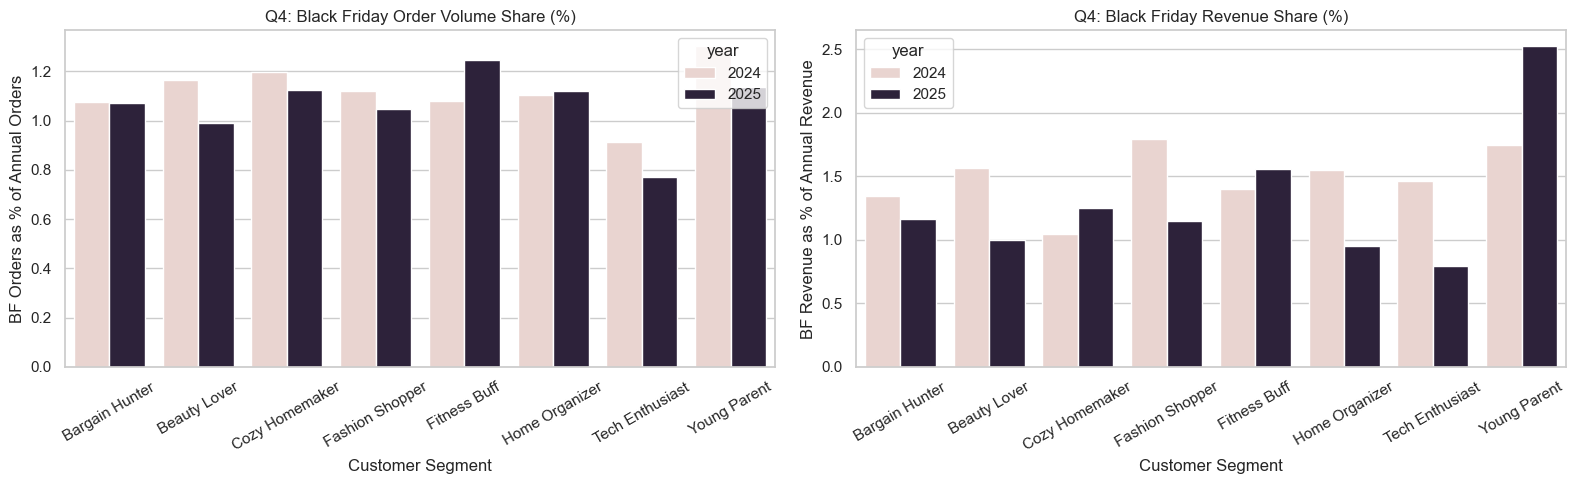

In [32]:
# Q4: Black Friday sales impact (bar charts: volume & revenue share by segment)
q4 = order_level.copy()

annual = (
    q4.groupby(["year", "customer_segment"], as_index=False)
    .agg(
        annual_orders=("order_id", "nunique"),
        annual_revenue=("order_revenue", "sum")
    )
)

bf = (
    q4[q4["is_black_friday"]]
    .groupby(["year", "customer_segment"], as_index=False)
    .agg(
        bf_orders=("order_id", "nunique"),
        bf_revenue=("order_revenue", "sum")
    )
)

impact = annual.merge(bf, on=["year", "customer_segment"], how="left").fillna(0)
impact["bf_order_share_pct"] = np.where(impact["annual_orders"] > 0, impact["bf_orders"] / impact["annual_orders"] * 100, 0)
impact["bf_revenue_share_pct"] = np.where(impact["annual_revenue"] > 0, impact["bf_revenue"] / impact["annual_revenue"] * 100, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=impact, x="customer_segment", y="bf_order_share_pct", hue="year", ax=axes[0])
axes[0].set_title("Q4: Black Friday Order Volume Share (%)")
axes[0].set_xlabel("Customer Segment")
axes[0].set_ylabel("BF Orders as % of Annual Orders")
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=impact, x="customer_segment", y="bf_revenue_share_pct", hue="year", ax=axes[1])
axes[1].set_title("Q4: Black Friday Revenue Share (%)")
axes[1].set_xlabel("Customer Segment")
axes[1].set_ylabel("BF Revenue as % of Annual Revenue")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()



In [34]:
# Q5: Geographic heat map of customer value (assumption-compliant profit per customer)
import plotly.express as px

state_value = (
    order_level.groupby("state", as_index=False)
    .agg(
        total_profit=("order_profit", "sum"),
        unique_customers=("buyer_id", "nunique"),
        total_orders=("order_id", "nunique")
    )
)

state_value["profit_per_customer"] = state_value["total_profit"] / state_value["unique_customers"]
state_value["profit_per_order"] = state_value["total_profit"] / state_value["total_orders"]

state_value["state"] = state_value["state"].astype(str).str.strip().str.upper()
state_value = state_value[state_value["state"].str.fullmatch(r"[A-Z]{2}", na=False)].copy()

fig = px.choropleth(
    state_value,
    locations="state",
    locationmode="USA-states",
    color="profit_per_customer",
    scope="usa",
    color_continuous_scale="YlGnBu",
    hover_data={
        "state": True,
        "profit_per_customer": ":.2f",
        "profit_per_order": ":.2f",
        "total_profit": ":.2f",
        "unique_customers": True,
        "total_orders": True,
    },
    title="Q5: Geographic Customer Value (Profit per Customer) by State"
)

fig.update_layout(
    title_x=0.5,
    margin=dict(l=20, r=20, t=60, b=20),
    coloraxis_colorbar=dict(title="Profit / Customer"),
)

fig.show()

